In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import pickle
import pyvisa
import time 
import os 
from datetime import datetime  
import nysg_tools as ny
import os
import pickle
import glob as glob
from scipy.optimize import curve_fit


In [ ]:
from cmath import sqrt

file_list = sorted(glob.glob("09h_50m_25s/*.pkl"))

frequencies = []
r_values = []
phases = []
x_mean = []
y_mean =[]
r_std_vals = []
x_std = []
y_std = []
for file in file_list:
    with open(file, "rb") as f:
        data = pickle.load(f)
        # print(data)
        frequencies.append(data['frequency_Hz'])
        r_values.append(np.abs(data['R_V_mean']))
        r_std_vals.append(data['R_V_std']  )
        phases.append(data['Theta_deg_mean']) 

        x_mean.append(np.real(data['X_V_mean'])) 
        y_mean.append(np.real(data['Y_V_mean']) )

        x_std.append(data['X_V_std']) 
        y_std.append(data['Y_V_std'] )
        # etc...

f = np.array(frequencies)
r = np.array(r_values)
r_err = np.array(r_std_vals)
theta = np.array(phases)
x = np.array(x_mean)
y = np.array(y_mean)
x_s = np.array(x_std)
y_s = np.array(y_std)

In [6]:
import pandas as pd
pd.DataFrame({
    'frequency_Hz': f,
    'R_V_mean': r,
    'R_V_err': r_err }).to_csv('processed_data2.csv', index=False)



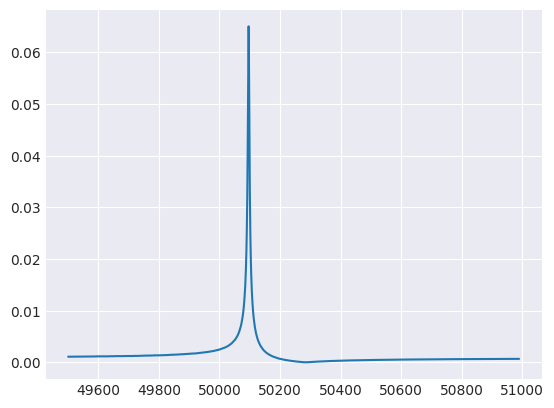

In [223]:
plt.plot(f,r)

In [214]:
import numpy as np

def transfer_function_mag(f, R, L, C, C2):
    R2 = 10000
    Cp = 300e-12  # 300 pF parasitic capacitance from cables/lock-in

    w = 2 * np.pi * f 

    # Piezoelectric impedance
    Zm = R + 1j * (w * L - 1 / (w * C))
    Z_pzt = 1 / (1 / Zm + 1j * w * C2)

    # Measurement impedance (R2 in parallel with Cp)
    Z_meas = 1 / (1 / R2 + 1j * w * Cp) 
    
    # Transfer function (Complex)
    H = Z_meas / (Z_pzt + Z_meas) 

    # Return ONLY the magnitude for curve_fit
    return np.abs(H)

In [204]:
def transfer_function(f, R, L, C, C2):
    R2 = 10000
    Cp = 200e-12  # 300 pF parasitic capacitance

    w = 2 * np.pi * f 

    # Piezoelectric impedance
    Zm = R + 1j * (w * L - 1 / (w * C))
    Z_pzt = 1 / (1 / Zm + 1j * w * C2)

    # Measurement impedance (R2 in parallel with Cp)
    Z_meas = 1 / (1 / R2 + 1j * w * Cp) 
    
    # Transfer function
    H = Z_meas / (Z_pzt + Z_meas) 

    return H

/home/nysg/Miniforge3/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/nysg/Miniforge3/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


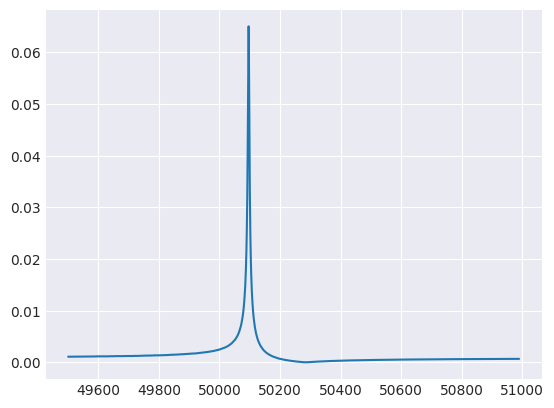

In [220]:
plt.plot(f,r)

R  = 106379.83 Ohms
L  = 3617.66 H
C  = 2.79e-15 F
C2 = 3.69e-13 F


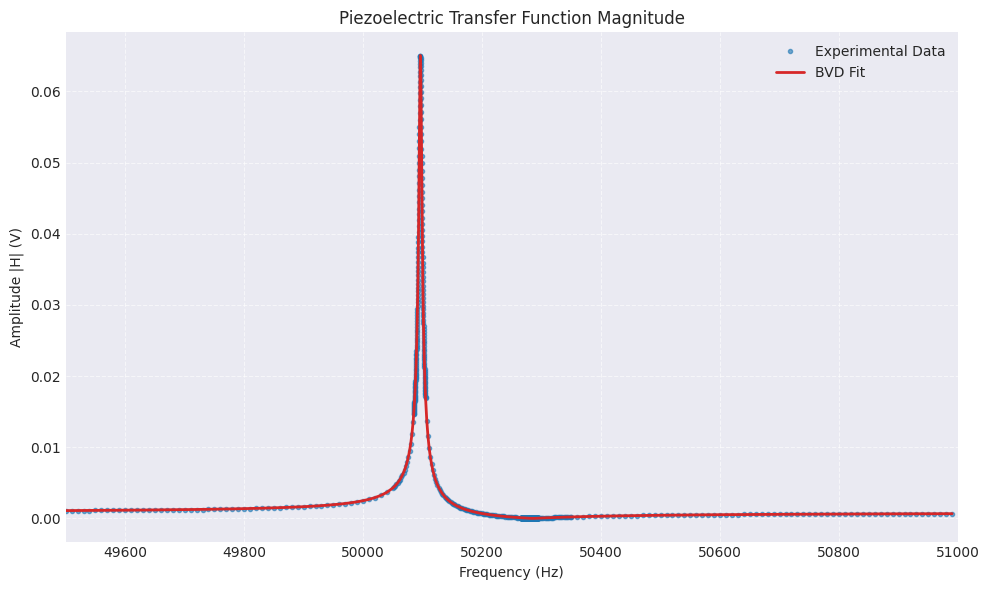

AttributeError: module 'matplotlib.pyplot' has no attribute 'scale'

In [244]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Load your data
df = pd.read_csv('processed_data.csv')
f = df['frequency_Hz'].values
H_exp = df['R_V_mean'].values

def transfer_function_mag(f, R, L, C, C2):
    R2 = 10000
    Cp = 300e-12 
    w = 2 * np.pi * f 
    Zm = R + 1j * (w * L - 1 / (w * C))
    Z_pzt = 1 / (1 / Zm + 1j * w * C2)
    Z_meas = 1 / (1 / R2 + 1j * w * Cp) 
    H = Z_meas / (Z_pzt + Z_meas) 
    return np.abs(H)

# 2. THE TRICK: Zoom in on the resonance peak for the fit
# This stops the optimizer from flattening the curve to fit the baseline noise
mask = (f > 49800) & (f < 50400)
f_zoom = f[mask]
H_zoom = H_exp[mask]

# 3. Apply the calculated physical seeds
p0_best = [106380, 3617.6, 2.79e-15, 3.69e-13]

# 4. Run the fit ONLY on the zoomed data
popt, pcov = curve_fit(transfer_function_mag, f_zoom, H_zoom, p0=p0_best, maxfev=10000)

R_fit, L_fit, C_fit, C2_fit = popt
print(f"R  = {R_fit:.2f} Ohms")
print(f"L  = {L_fit:.2f} H")
print(f"C  = {C_fit:.2e} F")
print(f"C2 = {C2_fit:.2e} F")

# 5. Plot the FULL data array against the new fit
plt.figure(figsize=(10, 6))
plt.plot(f, H_exp, 'o', label='Experimental Data', color='#1f77b4', markersize=3, alpha=0.6)
plt.plot(f, transfer_function_mag(f, *popt), '-', label='BVD Fit', color='#d62728', linewidth=2)

plt.title('Piezoelectric Transfer Function Magnitude')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude |H| (V)')
plt.xlim(49500, 51000)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

plt.scale('log')

In [205]:

def fit_func(f_concat, R, L, C, C2):

    N = len(f_concat) // 2 
    f = f_concat[:N]

    H = transfer_function(f, R, L, C, C2)

    return np.concatenate([H.real, H.imag])

In [242]:
freq_fit = np.concatenate([np.array(f), np.array(f)])

initial_guess = [106380, 3617.6, 2.79e-15, 3.69e-13]

X_data = np.array(x)
Y_data = np.array(y)

data_to_fit = np.concatenate([np.array(X_data), np.array(Y_data)])


# Create the error vector to match our concatenated data (Real + Imaginary)
data_errors = np.concatenate([x_s, y_s])

# Update curve_fit to include the sigma parameter
popt, pcov = curve_fit(
    fit_func, 
    freq_fit, 
    data_to_fit, 
    p0=initial_guess, 
    # sigma=data_errors,  # This adds the weighting!
    # absolute_sigma=True, 
    maxfev=10000000
)

R_fit, L_fit, C_fit, C2_fit = popt
print(f"Fitted parameters: R = {R_fit:.4f} Ohms, L = {L_fit:.4f} H, C = {C_fit:.4e} F, C2 = {C2_fit:.4e} F")


Fitted parameters: R = 9030.7977 Ohms, L = 523.2062 H, C = 1.9291e-14 F, C2 = 3.0202e-12 F


/tmp/ipykernel_43988/3824467274.py:30: UserWarning: Glyph 129480 (\N{BUTTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/nysg/Miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129480 (\N{BUTTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


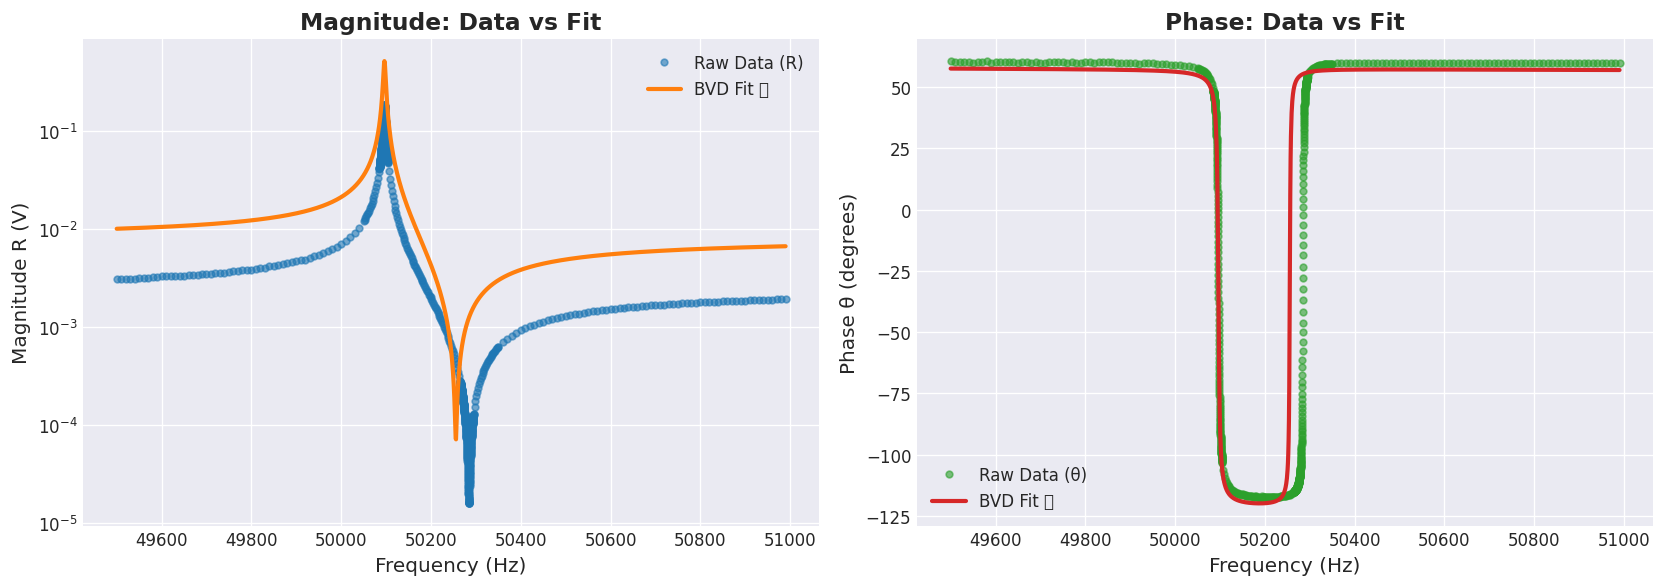

In [243]:
# Generate a high-res frequency array for a butter-smooth fit line 🧈
f_smooth = np.linspace(min(frequencies), max(frequencies), 2000)
H_fit = transfer_function(f_smooth, R_fit, L_fit, C_fit, C2_fit)

# Calculate R (Magnitude) and Theta (Phase in degrees) for the model
R_model = np.abs(H_fit)
Theta_model = np.angle(H_fit, deg=True)

# Make it pretty
plt.style.use('seaborn-v0_8-darkgrid') 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# --- Magnitude R ---
ax1.plot(frequencies, np.multiply(r_values, 2.828), 'o', color='#1f77b4', markersize=4, alpha=0.6, label='Raw Data (R)')
ax1.plot(f_smooth, R_model, '-', color='#ff7f0e', linewidth=2.5, label='BVD Fit 🧈')
ax1.set_yscale('log')
ax1.set_xlabel('Frequency (Hz)', fontsize=12)
ax1.set_ylabel('Magnitude R (V)', fontsize=12)
ax1.set_title('Magnitude: Data vs Fit', fontsize=14, fontweight='bold')
ax1.legend(loc='best')

# --- Phase Theta ---
ax2.plot(frequencies, phases, 'o', color='#2ca02c', markersize=4, alpha=0.6, label='Raw Data (θ)')
ax2.plot(f_smooth, Theta_model, '-', color='#d62728', linewidth=2.5, label='BVD Fit 🧈')
ax2.set_xlabel('Frequency (Hz)', fontsize=12)
ax2.set_ylabel('Phase θ (degrees)', fontsize=12)
ax2.set_title('Phase: Data vs Fit', fontsize=14, fontweight='bold')
ax2.legend(loc='best')

plt.tight_layout()
plt.show()

RESIDUALS & CHI2 VIBE CHECK
Sum of Squared Residuals: 4.7484e-02
Reduced Chi-Squared (χ²/dof): 3.1911e-05
Mean Abs Error: 3.8935e-03 V


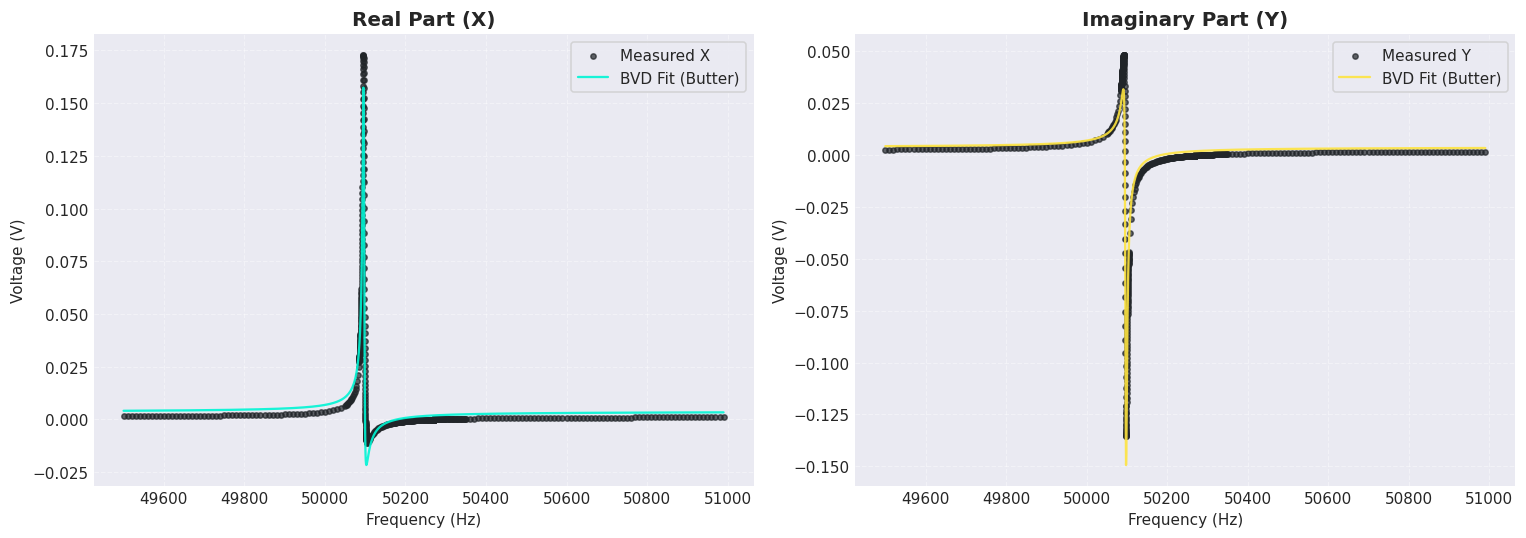

In [61]:
# 1. Generate smooth fit
f_smooth = np.linspace(min(frequencies), max(frequencies), 2000)
H_smooth = transfer_function(f_smooth, R_fit, L_fit, C_fit, C2_fit)
X_smooth, Y_smooth = np.real(H_smooth), np.imag(H_smooth)

# 2. Stats Recap
y_model_at_data = fit_func(freq_fit, *popt)
residuals = data_to_fit - y_model_at_data
ssr = np.sum(residuals**2)
dof = len(data_to_fit) - len(popt)
reduced_chi2 = ssr / dof

print(f"{'='*30}")
print(f"RESIDUALS & CHI2 VIBE CHECK")
print(f"{'='*30}")
print(f"Sum of Squared Residuals: {ssr:.4e}")
print(f"Reduced Chi-Squared (χ²/dof): {reduced_chi2:.4e}")
print(f"Mean Abs Error: {np.mean(np.abs(residuals)):.4e} V")

# 3. Chiller Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=110)

# Real Part (X)
# Data is zorder 3 (top), Fit is zorder 2 (behind)
ax1.scatter(frequencies, x_rms, color='#212529', s=12, alpha=0.7, label='Measured X', zorder=1)
ax1.plot(f_smooth, X_smooth, color='#00f5d4', linewidth=1.5, alpha=0.9, label='BVD Fit (Butter)', zorder=2)
ax1.set_title("Real Part (X)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Voltage (V)")
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(frameon=True)

# Imaginary Part (Y)
ax2.scatter(frequencies, y_rms, color='#212529', s=12, alpha=0.7, label='Measured Y', zorder=1)
ax2.plot(f_smooth, Y_smooth, color='#fee440', linewidth=1.5, alpha=0.9, label='BVD Fit (Butter)', zorder=2)
ax2.set_title("Imaginary Part (Y)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Voltage (V)")
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()

RESIDUAL STATS (VOLTS)
X - Mean: -2.85e-04 | Std Dev: 5.36e-03
Y - Mean: 7.98e-04 | Std Dev: 5.85e-03



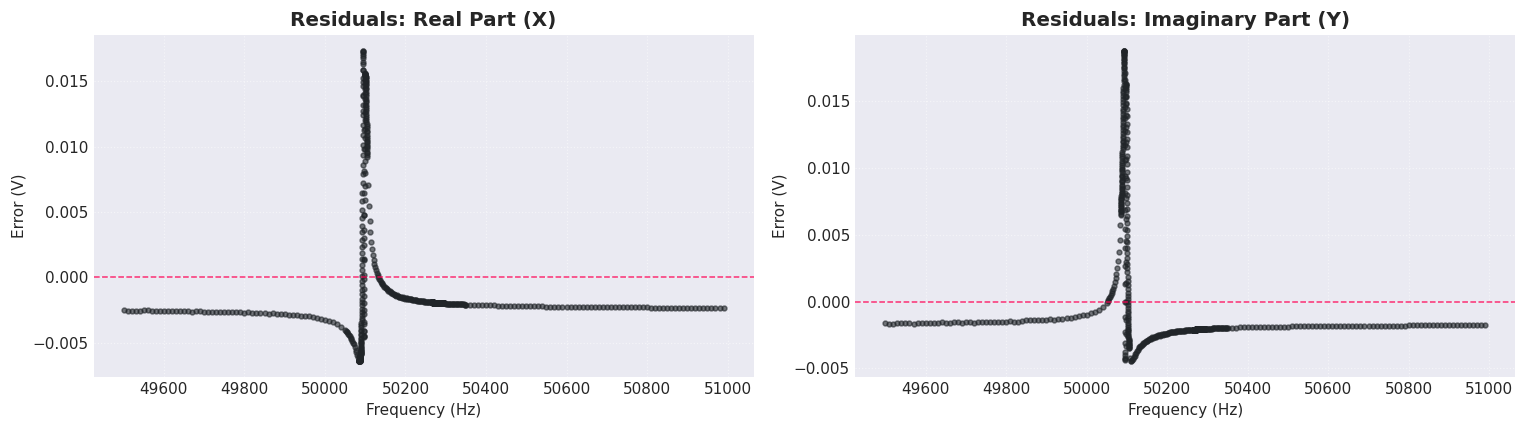

In [62]:

# 1. Calculate the residuals for each component
# We need the model values exactly at the measured frequencies
H_at_data = transfer_function(np.array(frequencies), R_fit, L_fit, C_fit, C2_fit)
res_x = x_rms - np.real(H_at_data)
res_y = y_rms - np.imag(H_at_data)

# 2. Print the numerical vibe check
print(f"{'='*30}")
print(f"RESIDUAL STATS (VOLTS)")
print(f"{'='*30}")
print(f"X - Mean: {np.mean(res_x):.2e} | Std Dev: {np.std(res_x):.2e}")
print(f"Y - Mean: {np.mean(res_y):.2e} | Std Dev: {np.std(res_y):.2e}")
print(f"{'='*30}\n")

# 3. Plotting the residuals
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), dpi=110)

# Residuals X
ax1.scatter(frequencies, res_x, color='#212529', s=10, alpha=0.6, label='X Residuals')
ax1.axhline(0, color='#ff0054', linestyle='--', linewidth=1, alpha=0.8) # Zero line
ax1.set_title("Residuals: Real Part (X)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Error (V)")
ax1.grid(True, linestyle=':', alpha=0.5)

# Residuals Y
ax2.scatter(frequencies, res_y, color='#212529', s=10, alpha=0.6, label='Y Residuals')
ax2.axhline(0, color='#ff0054', linestyle='--', linewidth=1, alpha=0.8) # Zero line
ax2.set_title("Residuals: Imaginary Part (Y)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Error (V)")
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()